In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
data = pd.read_csv("./wine_dataset.csv")
data.head()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,style
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [26]:
data.describe()
data.info()
data = data.drop(columns=['quality'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  style                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


#### Fixes acidity

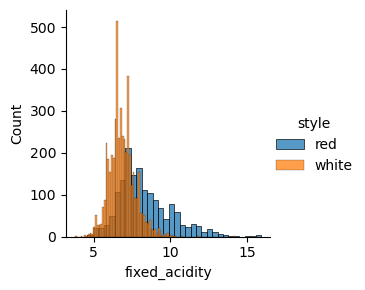

In [18]:
g = sns.FacetGrid(data=data, hue='style')
g.map(sns.histplot, 'fixed_acidity').add_legend()
plt.show()

Affichage de l'histogramme pour : fixed_acidity


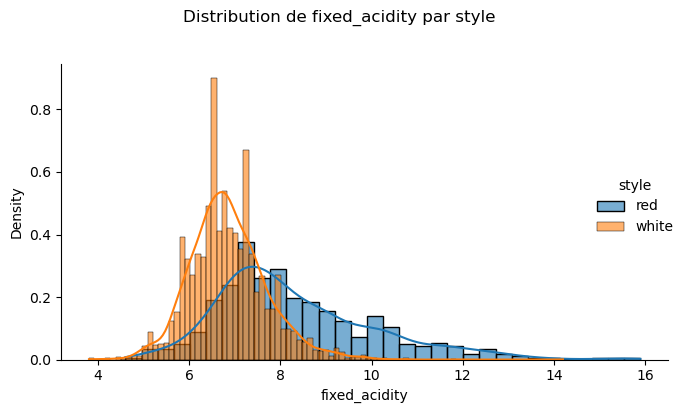

Affichage de l'histogramme pour : volatile_acidity


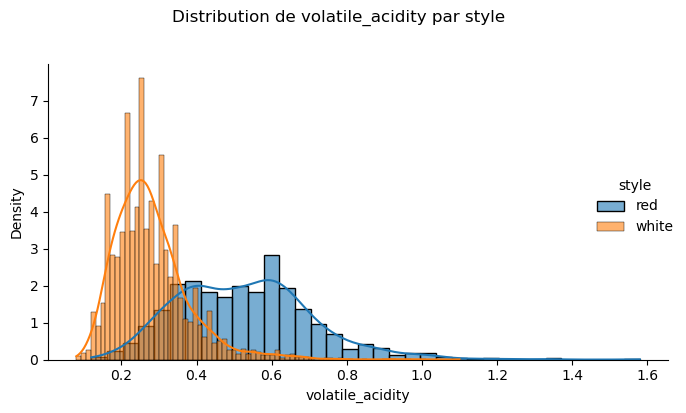

Affichage de l'histogramme pour : citric_acid


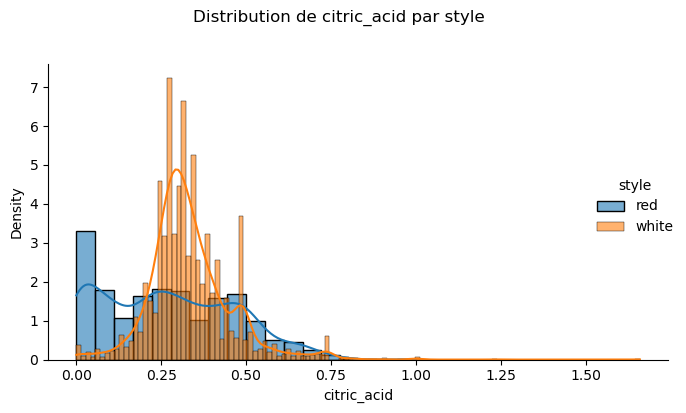

Affichage de l'histogramme pour : residual_sugar


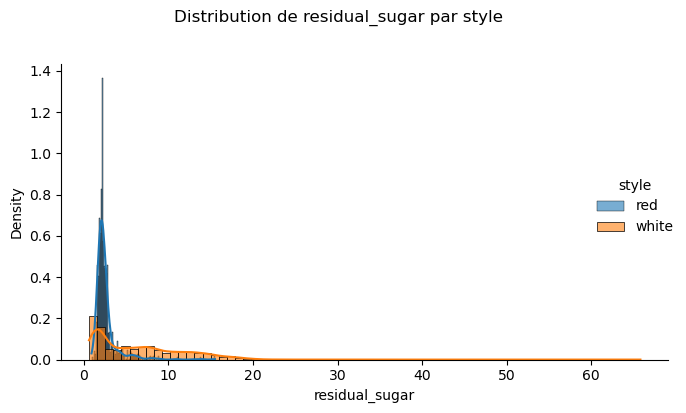

Affichage de l'histogramme pour : chlorides


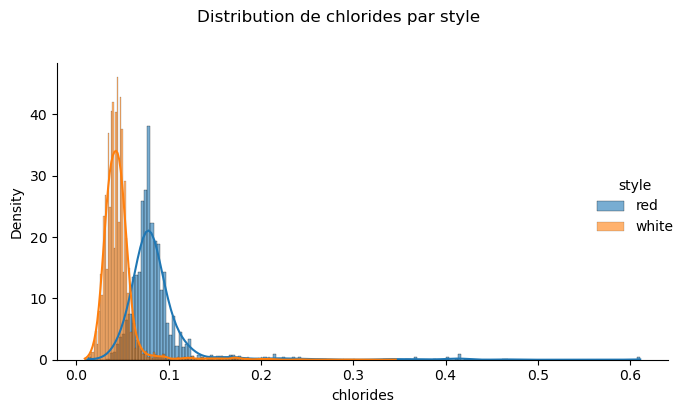

Affichage de l'histogramme pour : free_sulfur_dioxide


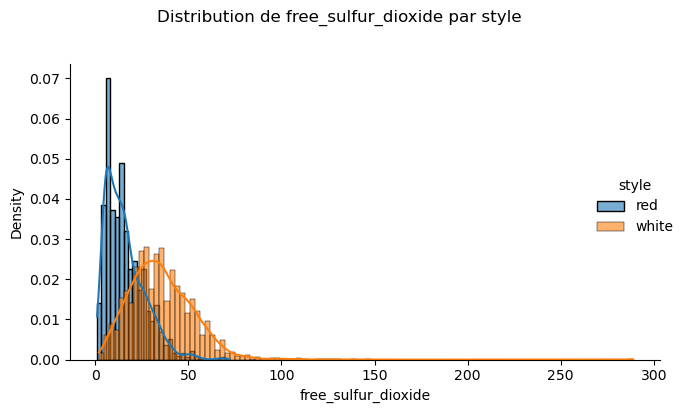

Affichage de l'histogramme pour : total_sulfur_dioxide


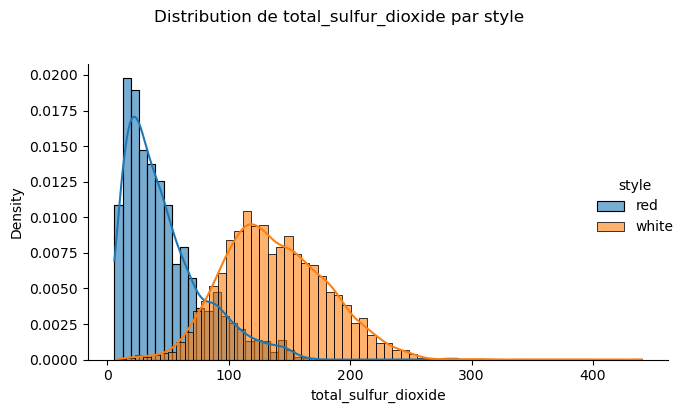

Affichage de l'histogramme pour : density


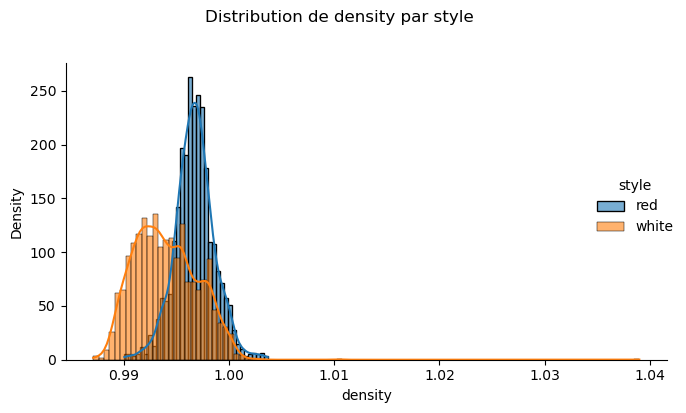

Affichage de l'histogramme pour : pH


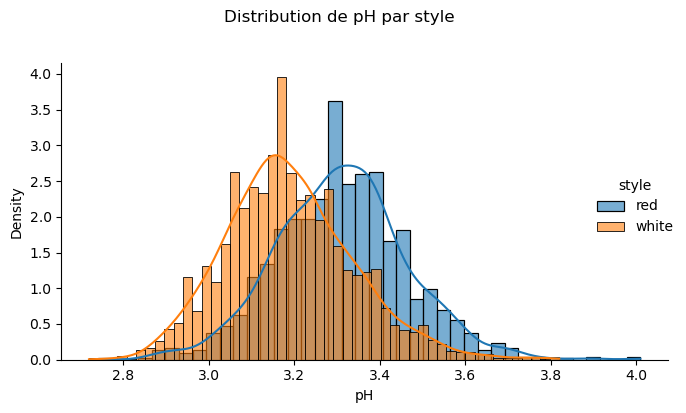

Affichage de l'histogramme pour : sulphates


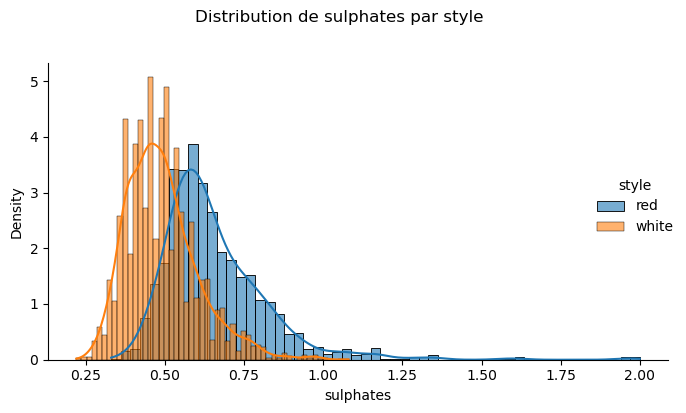

Affichage de l'histogramme pour : alcohol


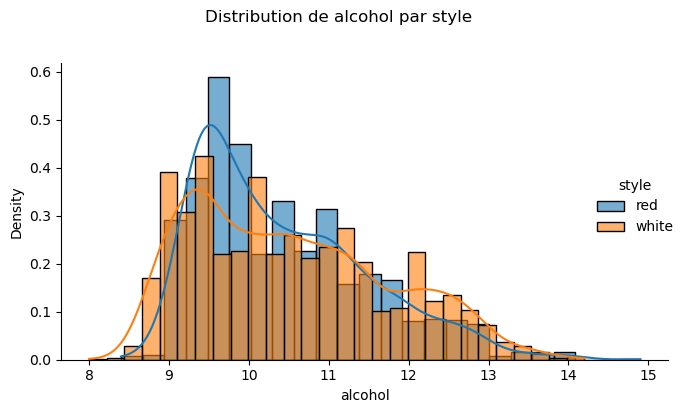

In [23]:
# Liste des colonnes numériques à tracer (on exclut 'style' ici car c'est la variable de regroupement)
cols_to_plot = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

# Boucle sur chaque variable pour créer un graphique
for col in cols_to_plot:
    print(f"Affichage de l'histogramme pour : {col}")
    g = sns.FacetGrid(data=data, hue='style', height=4, aspect=1.5)
    g.map(sns.histplot, col, kde=True, stat="density", common_norm=False, alpha=0.6).add_legend()
    g.fig.suptitle(f"Distribution de {col} par style", y=1.02)
    plt.tight_layout()
    plt.show()

In [27]:
data.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'style'],
      dtype='object')

In [40]:
data_reduced= data[['chlorides','total_sulfur_dioxide','residual_sugar','volatile_acidity','style']]
print(data_reduced.head())
data_reduced.columns

   chlorides  total_sulfur_dioxide  residual_sugar  volatile_acidity style
0      0.076                  34.0             1.9              0.70   red
1      0.098                  67.0             2.6              0.88   red
2      0.092                  54.0             2.3              0.76   red
3      0.075                  60.0             1.9              0.28   red
4      0.076                  34.0             1.9              0.70   red


Index(['chlorides', 'total_sulfur_dioxide', 'residual_sugar',
       'volatile_acidity', 'style'],
      dtype='object')

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_reduced.drop(columns='style'),
data_reduced['style'])

In [56]:
from sklearn.linear_model import LogisticRegression

# Initialisation du modèle
f = LogisticRegression()

# Entraînement du modèle sur les données
f.fit(X_train, y_train)

# Prédiction des classes pour les deux premières observations
predictions = f.predict(X_train.iloc[:5, :])

# Probabilités prédites pour les deux premières observations
probabilities = f.predict_proba(X_train.iloc[:5, :])

# Score (accuracy) du modèle sur l'ensemble d'entraînement
accuracy = f.score(X_train, y_train)
accuracy_test=f.score(X_test, y_test)


# Affichage des résultats
print("Prédictions train :", predictions)
print("Probabilités train :", probabilities)
print("Exactitude (score) train  :", accuracy)

print(';')


print("Exactitude (score) test :", accuracy_test)



Prédictions train : ['white' 'white' 'red' 'white' 'red']
Probabilités train : [[0.01715817 0.98284183]
 [0.0013209  0.9986791 ]
 [0.94420136 0.05579864]
 [0.00183773 0.99816227]
 [0.72575865 0.27424135]]
Exactitude (score) train  : 0.9597701149425287
;
Exactitude (score) test : 0.9556923076923077


In [ ]:
from sklearn.linear_model import Perceptron

(1625, 4)